# Import Required Libraries
Import the necessary libraries, including pandas and matplotlib.

In [7]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load Data
Load the data from execution_times_dy_align_blk.csv using pandas.

In [8]:
# Load Data
data = pd.read_csv('execution_times_dy_align_blk.csv')

# Display the first few rows of the dataframe to verify loading
data.head()

,Matrix Size,Kernel Size,Threads,Run ID,Execution Time (Microseconds),Correctness
0,256x256,3,1,1,6963.20,Correct!
1,256x256,3,1,2,7578.02,Correct!
2,256x256,3,1,3,7613.49,Correct!
3,256x256,3,1,4,7498.54,Correct!
4,256x256,3,1,5,7555.67,Correct!


# Process Data
Process the data to extract matrix sizes and kernel sizes, and prepare it for plotting.

# Plot Data
Use matplotlib to create plots of the execution times labeled by matrix size and split between different kernel sizes.

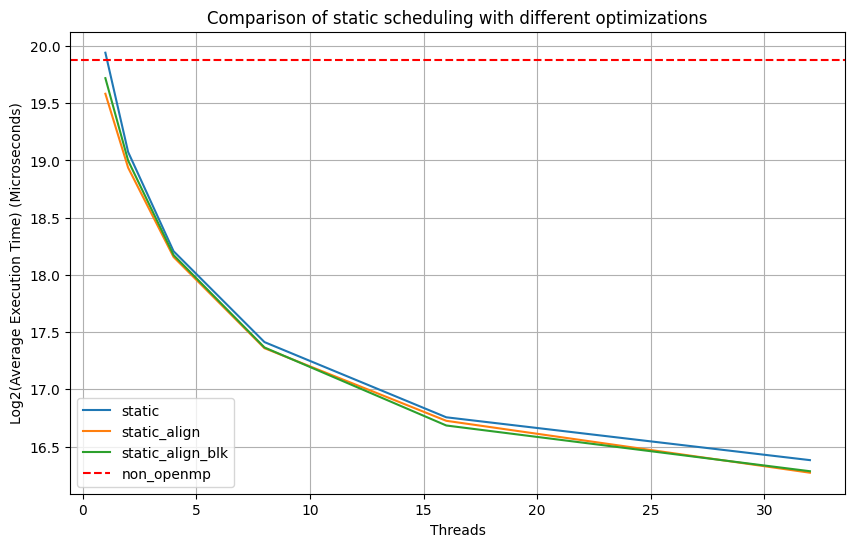

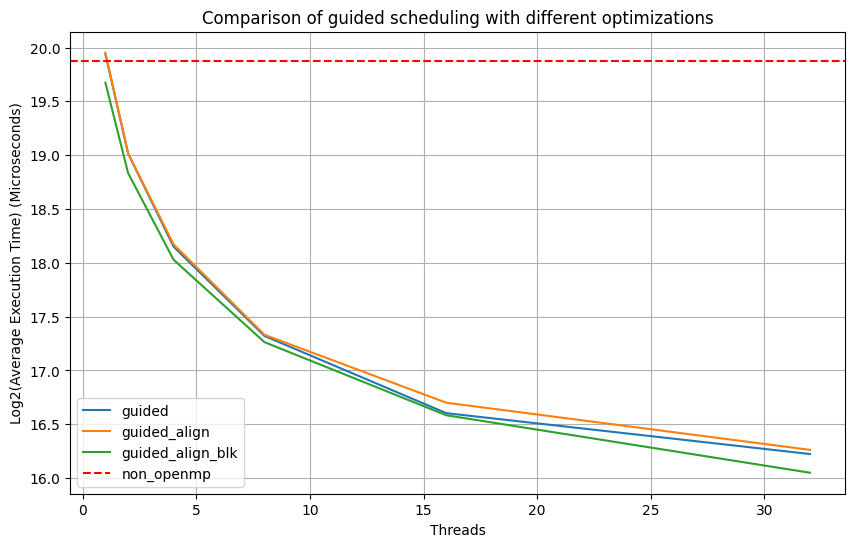

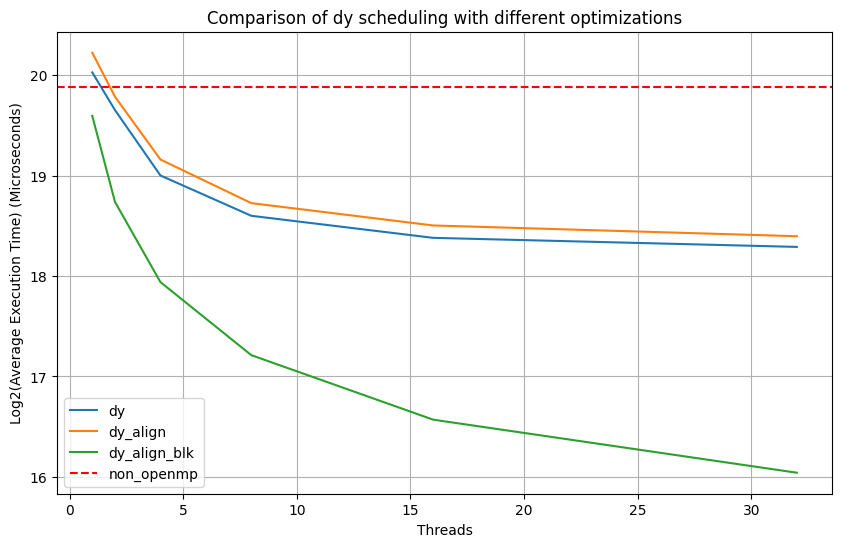

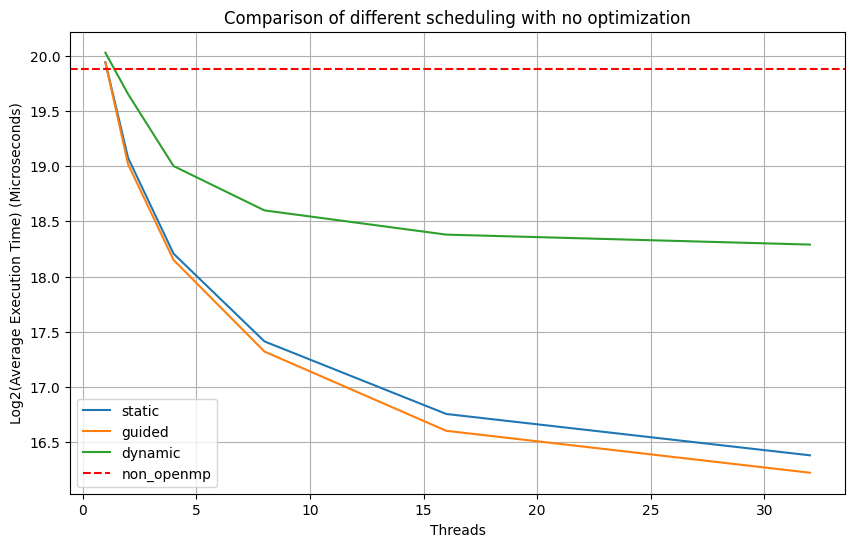

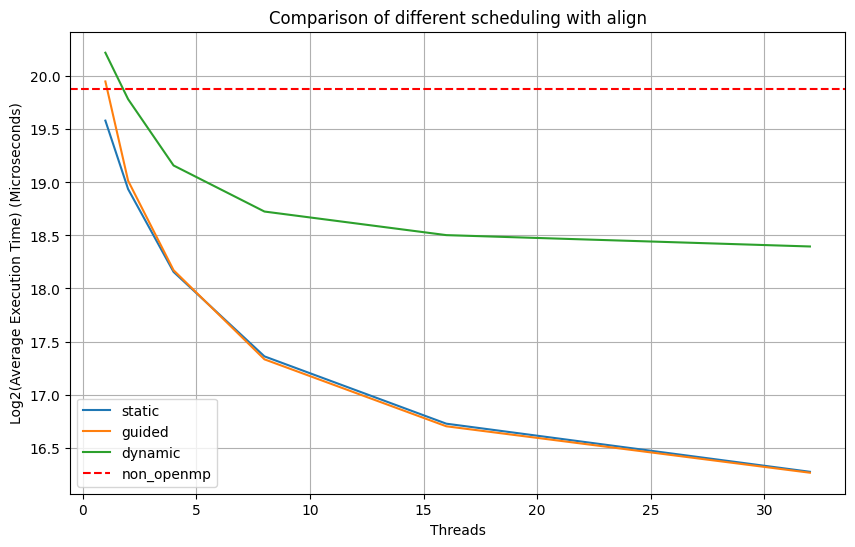

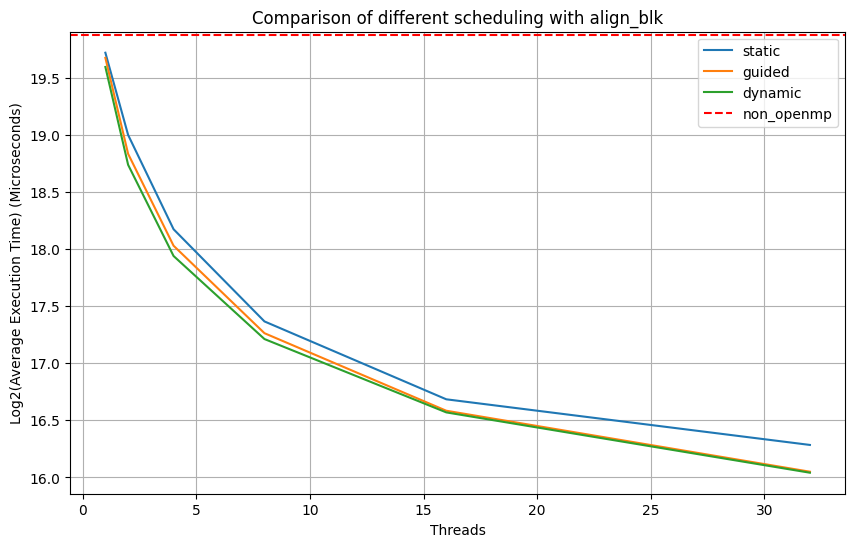

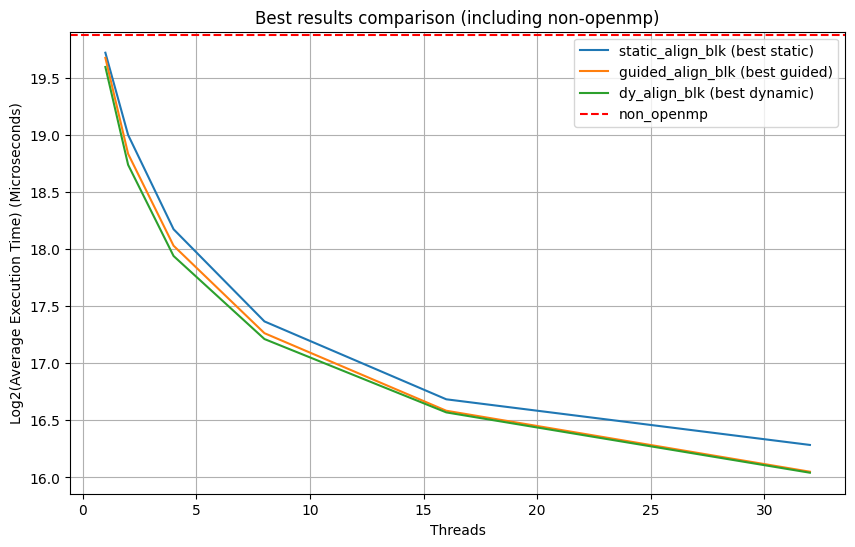

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# File names
files = [
    "execution_times_non_openmp.csv",
    "execution_times_static.csv",
    "execution_times_static_align.csv",
    "execution_times_static_align_blk.csv",
    "execution_times_guided.csv",
    "execution_times_guided_align.csv",
    "execution_times_guided_align_blk.csv",
    "execution_times_dy.csv",
    "execution_times_dy_align.csv",
    "execution_times_dy_align_blk.csv",
]

# Load data
data = {}
for file in files:
    label = file.replace("execution_times_", "").replace(".csv", "")
    df = pd.read_csv(file)
    df = df.dropna(subset=['Execution Time (Microseconds)'])  # Drop rows with missing execution times
    data[label] = df

# Group by threads and calculate average execution time
avg_times = {}
for key, df in data.items():
    avg_times[key] = df.groupby('Threads')['Execution Time (Microseconds)'].mean().reset_index()

# Apply log2 transformation to the execution times
for key, df in avg_times.items():
    df['Log2 Execution Time'] = np.log2(df['Execution Time (Microseconds)'])

# Extract the log2 execution time for non_openmp (single-threaded)
non_openmp_log2 = avg_times['non_openmp']['Log2 Execution Time'].iloc[0]

# 1. Compare results with the same scheduling but different optimizations
scheduling_types = ["static", "guided", "dy"]
for sched in scheduling_types:
    plt.figure(figsize=(10, 6))
    plt.title(f"Comparison of {sched} scheduling with different optimizations")
    plt.plot(avg_times[sched]['Threads'], avg_times[sched]['Log2 Execution Time'], label=f"{sched}")
    plt.plot(avg_times[f"{sched}_align"]['Threads'], avg_times[f"{sched}_align"]['Log2 Execution Time'], label=f"{sched}_align")
    plt.plot(avg_times[f"{sched}_align_blk"]['Threads'], avg_times[f"{sched}_align_blk"]['Log2 Execution Time'], label=f"{sched}_align_blk")
    plt.axhline(non_openmp_log2, color='red', linestyle='--', label="non_openmp")
    plt.xlabel("Threads")
    plt.ylabel("Log2(Average Execution Time) (Microseconds)")
    plt.legend()
    plt.grid()
    plt.savefig(f"{sched}_optimization_comparison_log2.png")
    plt.show()

# 2. Compare results with the same optimization but different scheduling
optimizations = ["", "align", "align_blk"]
for opt in optimizations:
    plt.figure(figsize=(10, 6))
    title_opt = "no optimization" if opt == "" else opt
    plt.title(f"Comparison of different scheduling with {title_opt}")
    plt.plot(avg_times[f"static{('_' + opt) if opt else ''}"]['Threads'], avg_times[f"static{('_' + opt) if opt else ''}"]['Log2 Execution Time'], label="static")
    plt.plot(avg_times[f"guided{('_' + opt) if opt else ''}"]['Threads'], avg_times[f"guided{('_' + opt) if opt else ''}"]['Log2 Execution Time'], label="guided")
    plt.plot(avg_times[f"dy{('_' + opt) if opt else ''}"]['Threads'], avg_times[f"dy{('_' + opt) if opt else ''}"]['Log2 Execution Time'], label="dynamic")
    plt.axhline(non_openmp_log2, color='red', linestyle='--', label="non_openmp")
    plt.xlabel("Threads")
    plt.ylabel("Log2(Average Execution Time) (Microseconds)")
    plt.legend()
    plt.grid()
    plt.savefig(f"scheduling_comparison_{opt if opt else 'no_opt'}_log2.png")
    plt.show()

# 3. Compare the best results from different scheduling and non-openmp
plt.figure(figsize=(10, 6))
plt.title("Best results comparison (including non-openmp)")
plt.plot(avg_times["static_align_blk"]['Threads'], avg_times["static_align_blk"]['Log2 Execution Time'], label="static_align_blk (best static)")
plt.plot(avg_times["guided_align_blk"]['Threads'], avg_times["guided_align_blk"]['Log2 Execution Time'], label="guided_align_blk (best guided)")
plt.plot(avg_times["dy_align_blk"]['Threads'], avg_times["dy_align_blk"]['Log2 Execution Time'], label="dy_align_blk (best dynamic)")
plt.axhline(non_openmp_log2, color='red', linestyle='--', label="non_openmp")
plt.xlabel("Threads")
plt.ylabel("Log2(Average Execution Time) (Microseconds)")
plt.legend()
plt.grid()
plt.savefig("best_results_comparison_log2.png")
plt.show()

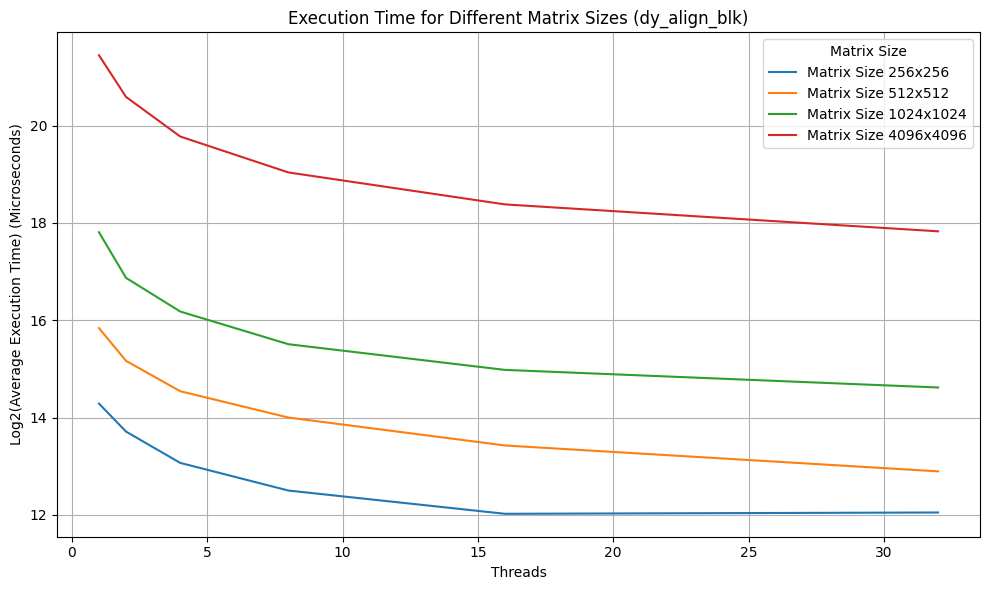

In [19]:
# Identify the best-performing optimization strategy
best_strategy = "dy_align_blk"  # Replace this with the actual best-performing strategy if different

# Group by matrix size and threads, then calculate average execution time
matrix_size_comparison = data[best_strategy].groupby(['Matrix Size', 'Threads'])['Execution Time (Microseconds)'].mean().reset_index()

# Apply log2 transformation to the execution times
matrix_size_comparison['Log2 Execution Time'] = np.log2(matrix_size_comparison['Execution Time (Microseconds)'])

# Sort matrix sizes numerically
# Extract the numeric value from the matrix size (e.g., "256x256" -> 256)
matrix_size_comparison['Matrix Size Numeric'] = matrix_size_comparison['Matrix Size'].apply(lambda x: int(x.split('x')[0]))
matrix_size_comparison = matrix_size_comparison.sort_values(by=['Matrix Size Numeric', 'Threads'])

# Plot execution time for different matrix sizes
plt.figure(figsize=(10, 6))
plt.title(f"Execution Time for Different Matrix Sizes ({best_strategy})")
for matrix_size in sorted(matrix_size_comparison['Matrix Size'].unique(), key=lambda x: int(x.split('x')[0])):
    subset = matrix_size_comparison[matrix_size_comparison['Matrix Size'] == matrix_size]
    plt.plot(subset['Threads'], subset['Log2 Execution Time'], label=f"Matrix Size {matrix_size}")

plt.xlabel("Threads")
plt.ylabel("Log2(Average Execution Time) (Microseconds)")
plt.legend(title="Matrix Size", loc="best")  # Keep the legend inside the graph area
plt.grid()
plt.tight_layout()  # Adjust layout to ensure everything fits within the figure
plt.savefig(f"{best_strategy}_matrix_size_comparison_log2.png")
plt.show()